In [2]:
import warnings; warnings.filterwarnings('ignore')
import hashlib
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import librosa, soundfile as sf
from scipy.signal import lfilter
from scipy.spatial.distance import cdist
from sklearn.metrics import confusion_matrix, accuracy_score
from IPython.display import display

# ---------------- Tham số baseline (bảng 5.2 của đề) ----------------
FS = 16000
FRAME_MS, HOP_MS = 25, 10
WIN = int(FS*FRAME_MS/1000)      # 400 mẫu
HOP = int(FS*HOP_MS/1000)        # 160 mẫu
NFFT, N_MELS, N_MFCC, PREEMPH = 512, 24, 13, 0.97
TOP_DB, MARGIN_FRAMES = 35, 5    # endpoint detection (báo cáo ngưỡng đã dùng)
LABELS = ['bat','tat','len','xuong','trai','phai','dung']
VI = dict(bat='bật', tat='tắt', len='lên', xuong='xuống', trai='trái', phai='phải', dung='dừng')

ROOT, FIG = Path('dataset'), Path('figures')
FIG.mkdir(exist_ok=True)
plt.rcParams.update({'figure.dpi':110, 'axes.grid':True, 'grid.alpha':0.3, 'font.size':9})
print(f'WIN={WIN} mẫu, HOP={HOP} mẫu, NFFT={NFFT}, n_mels={N_MELS}, n_mfcc={N_MFCC}, alpha={PREEMPH}')

ValueError: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject

## A. Thu dữ liệu và kiểm tra chất lượng

In [ ]:
def load_audio(path):
    y, sr = librosa.load(path, sr=FS, mono=True)      # ép về 16 kHz mono
    return y / (np.max(np.abs(y)) + 1e-9)             # chuẩn hóa biên độ đỉnh = 1

def md5(p): return hashlib.md5(Path(p).read_bytes()).hexdigest()

FILES = {lab: sorted((ROOT/lab).glob('*.wav')) for lab in LABELS}
rows = []
for lab in LABELS:
    for f in FILES[lab]:
        y, sr = sf.read(f, always_2d=True)
        ch = y.shape[1]; y = y.mean(1)
        _, idx = librosa.effects.trim(y, top_db=35, frame_length=WIN, hop_length=HOP)
        rows.append(dict(label=lab, file=f.name, sr=sr, channels=ch, dur_s=len(y)/sr,
                         peak=np.abs(y).max(), clip_pct=100*np.mean(np.abs(y) >= 0.999),
                         lead_s=idx[0]/sr, trail_s=(len(y)-idx[1])/sr, md5=md5(f)))
qc = pd.DataFrame(rows)
summary = qc.groupby('label').agg(n_files=('file','count'), sr=('sr','first'), channels=('channels','first'),
                                  dur_s=('dur_s','mean'), peak_max=('peak','max'), clip_pct=('clip_pct','max'),
                                  lead_s=('lead_s','mean'), trail_s=('trail_s','mean'),
                                  n_unique_recordings=('md5','nunique')).loc[LABELS]
display(summary.round(3))
dup = summary[summary.n_unique_recordings < summary.n_files]
if len(dup):
    print('⚠️ CẢNH BÁO DỮ LIỆU: các lớp sau có nhiều file nhưng chỉ 1 bản ghi duy nhất (file trùng byte):', list(dup.index))
    print('   → test ≡ template (data leakage); DTW cùng từ = 0. Cần ghi âm 5 lần NÓI THẬT cho mỗi từ.')

REAL = {lab: [load_audio(f) for f in FILES[lab]] for lab in LABELS}   # 5 mảng/lớp
# Chia train/test TRƯỚC khi chọn template: 01-03 train, 04-05 test
SPLIT = {lab: dict(train=FILES[lab][:3], test=FILES[lab][3:]) for lab in LABELS}
print({lab: (len(s['train']), len(s['test'])) for lab, s in SPLIT.items()})

,n_files,sr,channels,dur_s,peak_max,clip_pct,lead_s,trail_s,n_unique_recordings
label,,,,,,,,,
bat,5,16000,1,0.648,0.586,0.0,0.11,0.248,1
tat,5,16000,1,0.600,0.508,0.0,0.16,0.220,1
len,5,16000,1,0.768,0.440,0.0,0.09,0.198,1
xuong,5,16000,1,0.864,0.433,0.0,0.10,0.214,1
trai,5,16000,1,0.864,0.446,0.0,0.12,0.194,1
phai,5,16000,1,0.888,0.502,0.0,0.19,0.198,1
dung,5,16000,1,0.744,0.391,0.0,0.09,0.204,1


⚠️ CẢNH BÁO DỮ LIỆU: các lớp sau có nhiều file nhưng chỉ 1 bản ghi duy nhất (file trùng byte): ['bat', 'tat', 'len', 'xuong', 'trai', 'phai', 'dung']
   → test ≡ template (data leakage); DTW cùng từ = 0. Cần ghi âm 5 lần NÓI THẬT cho mỗi từ.
{'bat': (3, 2), 'tat': (3, 2), 'len': (3, 2), 'xuong': (3, 2), 'trai': (3, 2), 'phai': (3, 2), 'dung': (3, 2)}


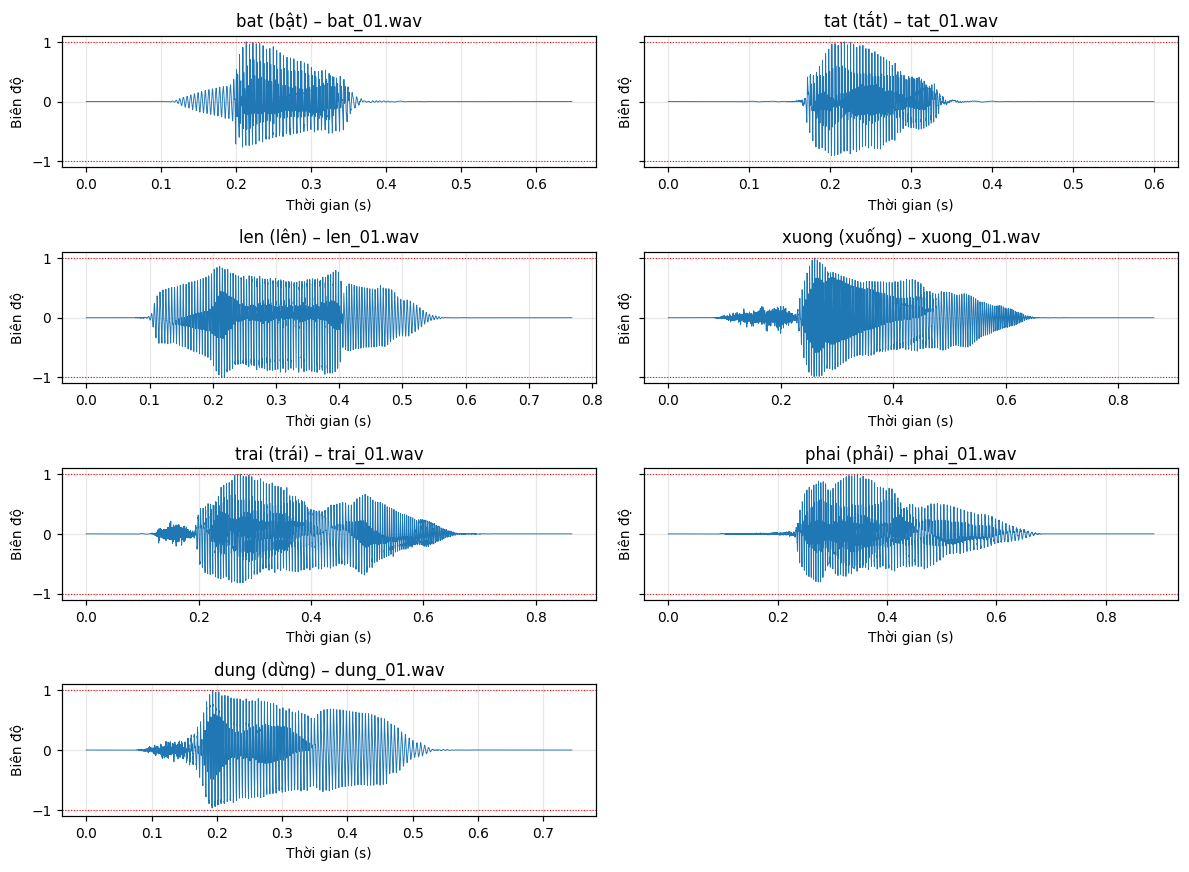

In [ ]:
fig, axes = plt.subplots(4, 2, figsize=(11, 8), sharey=True)
for ax, lab in zip(axes.ravel(), LABELS):
    y = REAL[lab][0]; t = np.arange(len(y))/FS
    ax.plot(t, y, lw=.6); ax.set_title(f'{lab} ({VI[lab]}) – {lab}_01.wav'); ax.set_xlabel('Thời gian (s)'); ax.set_ylabel('Biên độ')
    ax.axhline(1, c='r', ls=':', lw=.7); ax.axhline(-1, c='r', ls=':', lw=.7)
axes.ravel()[-1].axis('off')
plt.tight_layout(); plt.savefig(FIG/'A_waveforms.png'); plt.show()

In [ ]:
# ---- Dữ liệu tăng cường NHÂN TẠO (chỉ để minh họa DTW khi chưa có 5 lần nói thật) ----
def augment(y, rng):
    rate = rng.uniform(0.80, 1.25)                              # đổi tốc độ nói (thay đổi số frame)
    y2 = librosa.effects.time_stretch(y, rate=rate)
    y2 = librosa.effects.pitch_shift(y2, sr=FS, n_steps=rng.uniform(-1.5, 1.5))   # lệch cao độ/formant nhẹ
    y2 = lfilter([1.0, rng.uniform(-0.4, 0.4)], [1.0], y2)       # tô màu phổ (kênh thu khác)
    y2 = y2 * rng.uniform(0.5, 1.0)                              # khác mức âm lượng
    snr = rng.uniform(20, 30)                                    # nhiễu trắng SNR 20-30 dB
    n = rng.normal(size=len(y2)); n *= np.sqrt(np.mean(y2**2))/(10**(snr/20)*np.sqrt(np.mean(n**2)))
    y2 = y2 + n
    return y2/(np.max(np.abs(y2))+1e-9), rate

rng = np.random.default_rng(457)
AUG, AUG_RATE = {}, {}
for lab in LABELS:
    out = [augment(REAL[lab][0], rng) for _ in range(5)]        # 5 biến thể từ 1 bản ghi gốc
    AUG[lab] = [o[0] for o in out]; AUG_RATE[lab] = [round(o[1], 2) for o in out]
print('Hệ số tốc độ của 5 biến thể (bat):', AUG_RATE['bat'])
Path('dataset_aug').mkdir(exist_ok=True)
for lab in LABELS:
    (Path('dataset_aug')/lab).mkdir(exist_ok=True)
    for k, y in enumerate(AUG[lab]): sf.write(Path('dataset_aug')/lab/f'{lab}_{k+1:02d}.wav', y, FS)

Hệ số tốc độ của 5 biến thể (bat): [0.97, 1.03, 1.09, 0.81, 1.12]


**Nhận xét A.** 35 file (7 từ × 5), tất cả WAV mono, 16 kHz, 16-bit; không có clipping (peak gốc ≤ 0.59, 0% mẫu chạm ±1). Silence đầu ≈ 0.09–0.19 s, silence cuối ≈ 0.19–0.25 s (đo bằng ngưỡng 35 dB) – phần đầu hơi ngắn hơn khuyến nghị 0.2–0.5 s nhưng vẫn đủ để ước lượng nền nhiễu. Split train/test thực hiện trước khi chọn template (01–03 / 04–05).

**⚠️ Phát hiện quan trọng:** cột `n_unique_recordings = 1` cho cả 7 lớp, tức 5 file mỗi từ trùng byte (cùng MD5). Hệ quả: test ≡ template (data leakage), DTW cùng từ bằng 0 và accuracy 100% là *vô nghĩa* trên bộ này. Đây không phải lỗi code mà là lỗi dữ liệu. Vì vậy các phần E–G chạy song song trên (1) dữ liệu thật như đã nộp và (2) dữ liệu tăng cường nhân tạo (thư mục `dataset_aug/`, 5 biến thể/từ với tốc độ 0.8–1.25×, pitch ±1.5 semitone, lọc kênh, nhiễu SNR 20–30 dB, seed cố định). Bộ (2) vẫn sinh ra từ **một** bản ghi gốc nên chỉ minh họa hành vi của thuật toán, **không** đại diện cho độ chính xác ngoài thực tế.

## B. Đặc trưng miền thời gian: energy, RMS, magnitude, ZCR, autocorrelation

In [ ]:
def frame_signal(x, L=WIN, R=HOP, window=True):
    """Chia x thành frame chồng lấn; trả (n_frames, L). Cửa sổ Hamming w[n]=0.54-0.46cos(2πn/(L-1))."""
    if len(x) < L: x = np.pad(x, (0, L-len(x)))
    n = 1 + (len(x)-L)//R
    fr = x[np.arange(L)[None, :] + R*np.arange(n)[:, None]]
    return fr*np.hamming(L)[None, :] if window else fr

def short_time_features(x, eps=1e-10):
    fw = frame_signal(x, window=True)
    E   = np.sum(fw**2, 1)                       # E_r
    M   = np.sum(np.abs(fw), 1)                  # M_r
    RMS = np.sqrt(np.mean(fw**2, 1))             # RMS_r
    Edb = 10*np.log10(E+eps)                     # log-energy (dB)
    fr  = frame_signal(x, window=False)          # ZCR dùng cửa sổ chữ nhật
    s = np.where(fr >= 0, 1, -1)
    Z = np.sum(np.abs(np.diff(s, axis=1)), 1)/(2*fr.shape[1])      # Z_r = 1/(2L) Σ|sgn(x[m])-sgn(x[m-1])|
    t = (np.arange(len(E))*HOP + WIN/2)/FS
    return dict(E=E, M=M, RMS=RMS, Edb=Edb, ZCR=Z, t=t)

# kiểm tra công thức ZCR bằng ví dụ của đề: ~20 lần đổi dấu trên ~100 mẫu -> ZCR ≈ 0.20
xs = np.where((np.arange(101)//5) % 2 == 0, 1.0, -1.0)           # 20 lần đổi dấu
sg = np.where(xs >= 0, 1, -1)
print('ZCR ví dụ =', round(np.sum(np.abs(np.diff(sg)))/(2*len(xs)), 3), '(kỳ vọng ≈ 0.20)')

ZCR ví dụ = 0.198 (kỳ vọng ≈ 0.20)


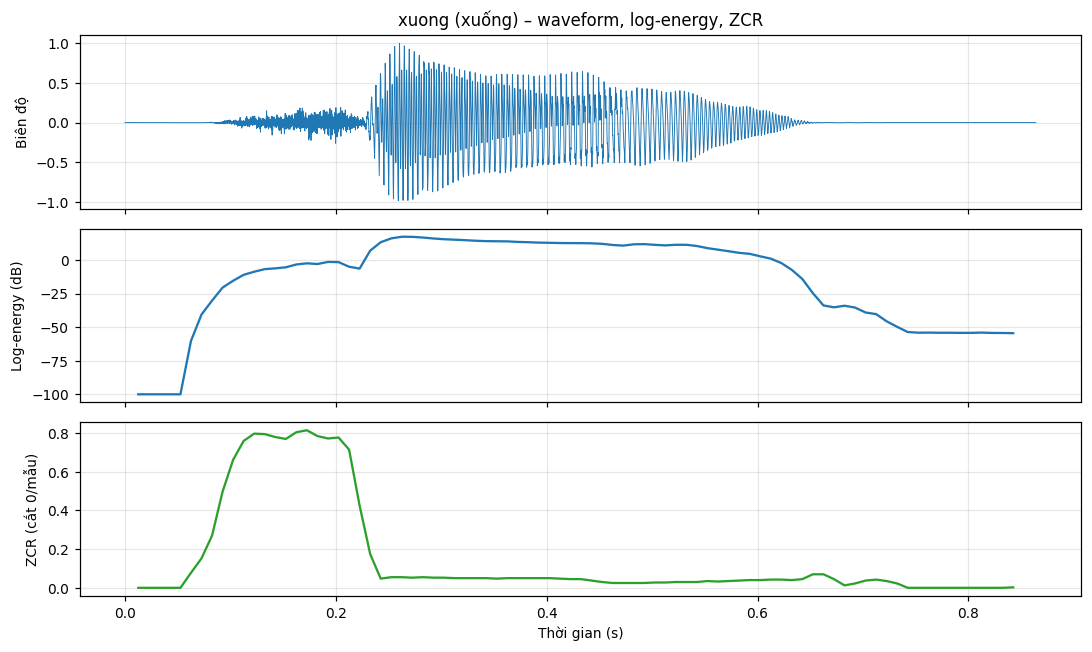

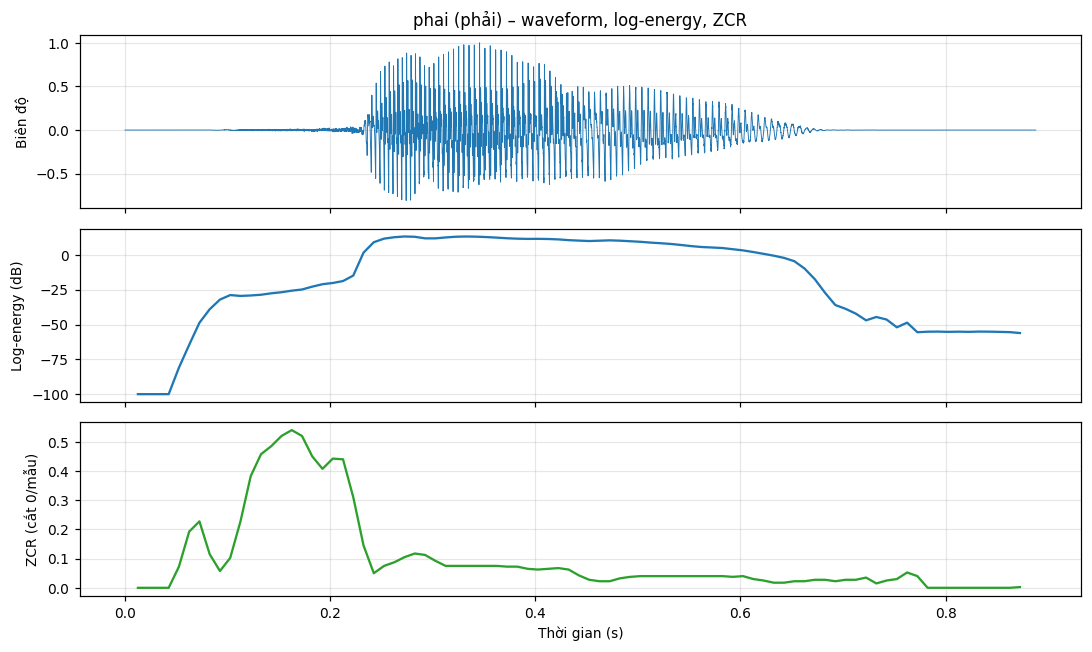

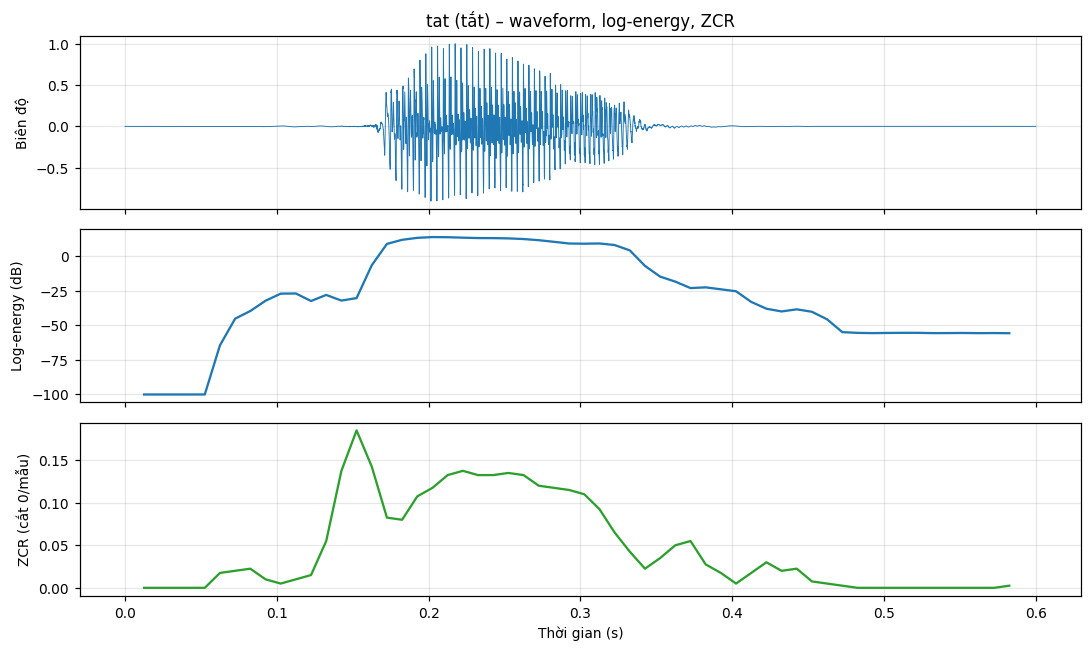

In [ ]:
def plot_time_features(y, title, save=None, extra=None):
    f = short_time_features(y); t = np.arange(len(y))/FS
    fig, ax = plt.subplots(3, 1, figsize=(10, 6), sharex=True)
    ax[0].plot(t, y, lw=.6); ax[0].set_ylabel('Biên độ'); ax[0].set_title(title)
    ax[1].plot(f['t'], f['Edb']); ax[1].set_ylabel('Log-energy (dB)')
    ax[2].plot(f['t'], f['ZCR'], c='tab:green'); ax[2].set_ylabel('ZCR (cắt 0/mẫu)'); ax[2].set_xlabel('Thời gian (s)')
    if extra: extra(ax, f)
    plt.tight_layout()
    if save: plt.savefig(FIG/save)
    plt.show(); return f

for lab in ['xuong', 'phai', 'tat']:      # từ có phụ âm vô thanh/xát ở đầu hoặc cuối
    plot_time_features(REAL[lab][0], f'{lab} ({VI[lab]}) – waveform, log-energy, ZCR', save=f'B_energy_zcr_{lab}.png')

In [ ]:
# Thống kê định lượng: silence vs. vùng giàu năng lượng (voiced) vs. vùng ZCR cao (unvoiced/xát)
rows = []
for lab in LABELS:
    f = short_time_features(REAL[lab][0]); peak = f['Edb'].max()
    sil = f['Edb'] < peak-50; voi = f['Edb'] > peak-12
    unv = (~sil) & (f['Edb'] <= peak-12) & (f['ZCR'] > 0.25)
    rows.append(dict(label=lab, silence_Edb=f['Edb'][sil].mean(), voiced_Edb=f['Edb'][voi].mean(),
                     silence_ZCR=f['ZCR'][sil].mean(), voiced_ZCR=f['ZCR'][voi].mean(),
                     n_unvoiced_frames=int(unv.sum()), unvoiced_ZCR=f['ZCR'][unv].mean() if unv.any() else np.nan))
display(pd.DataFrame(rows).set_index('label').round(2))

,silence_Edb,voiced_Edb,silence_ZCR,voiced_ZCR,n_unvoiced_frames,unvoiced_ZCR
label,,,,,,
bat,-63.91,10.01,0.00,0.06,0,NaN
tat,-60.63,11.25,0.01,0.11,0,NaN
len,-59.82,12.65,0.03,0.05,0,NaN
xuong,-58.06,12.53,0.02,0.05,15,0.70
trai,-61.88,10.91,0.02,0.05,7,0.62
phai,-60.06,9.60,0.03,0.06,11,0.45
dung,-59.74,13.22,0.03,0.05,7,0.63


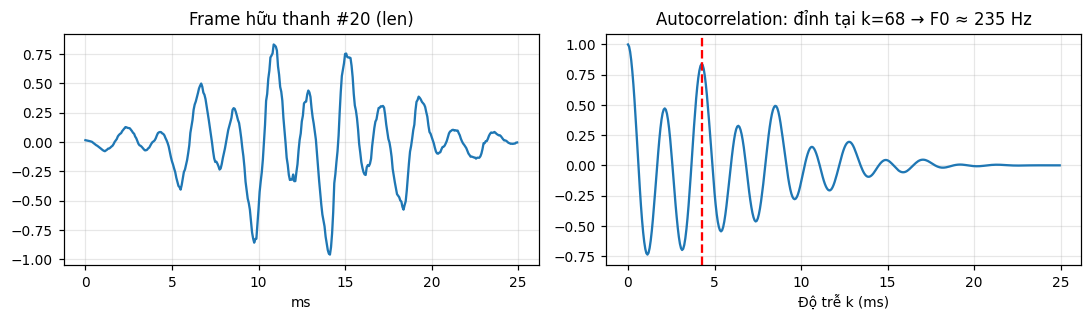

k0=68 mẫu, F0 ≈ Fs/k0 = 235.3 Hz, R[k0]=0.84 (càng gần 1 càng tuần hoàn/hữu thanh)


In [ ]:
# Short-time autocorrelation và pitch trên 1 frame hữu thanh (frame có năng lượng lớn nhất của "len")
y = REAL['len'][0]; fw = frame_signal(y, window=True); f = short_time_features(y)
r = int(np.argmax(f['Edb'])); x = fw[r]
R = np.correlate(x, x, 'full')[len(x)-1:]; R = R/R[0]                   # R_r[k] chuẩn hóa
lo, hi = int(FS/400), int(FS/70)                                        # tìm F0 trong 70–400 Hz
k0 = lo + int(np.argmax(R[lo:hi])); F0 = FS/k0
fig, ax = plt.subplots(1, 2, figsize=(10, 3))
ax[0].plot(np.arange(WIN)/FS*1000, x); ax[0].set_xlabel('ms'); ax[0].set_title(f'Frame hữu thanh #{r} (len)')
ax[1].plot(np.arange(len(R))/FS*1000, R); ax[1].axvline(k0/FS*1000, c='r', ls='--'); ax[1].set_xlabel('Độ trễ k (ms)')
ax[1].set_title(f'Autocorrelation: đỉnh tại k={k0} → F0 ≈ {F0:.0f} Hz'); plt.tight_layout(); plt.savefig(FIG/'B_autocorr.png'); plt.show()
print(f'k0={k0} mẫu, F0 ≈ Fs/k0 = {F0:.1f} Hz, R[k0]={R[k0]:.2f} (càng gần 1 càng tuần hoàn/hữu thanh)')

**Nhận xét B.** Trên 7 từ: log-energy của silence ≈ −58…−64 dB, vùng voiced ≈ +10…+13 dB (chênh ~70 dB) – energy tách silence khỏi tiếng rất rõ. ZCR của silence ≈ 0.00–0.03 (nền nhiễu thấp, chủ yếu tần số thấp) và voiced ≈ 0.05–0.11. Với các từ có phụ âm xát/vô thanh (`xuong`, `trai`, `phai`, `dung`) có 7–15 frame energy thấp hơn đỉnh hơn 12 dB nhưng ZCR rất cao (0.45–0.70): đúng đặc trưng unvoiced – năng lượng nhỏ nhưng đổi dấu liên tục. Ví dụ autocorrelation trên một frame hữu thanh của `len`: đỉnh tại k = 68 mẫu → F0 ≈ 235 Hz (R[k]=0.84, tuần hoàn mạnh).

Tóm tắt: *silence* = energy rất thấp + ZCR thấp; *voiced* = energy cao + ZCR thấp + autocorrelation có đỉnh rõ; *unvoiced* = energy thấp-vừa + ZCR cao + không có đỉnh pitch.

## C. Endpoint detection (log-energy + tinh chỉnh bằng ZCR)
**Ngưỡng dùng (báo cáo theo yêu cầu):** `TOP_DB = 35 dB` dưới đỉnh log-energy, nhưng không thấp hơn *nền nhiễu + 10 dB*; tinh chỉnh ZCR: mở rộng biên tối đa 10 frame khi `ZCR > 0.25` và log-energy còn cao hơn *nền + 6 dB*; vùng đệm `MARGIN_FRAMES = 5` (50 ms).

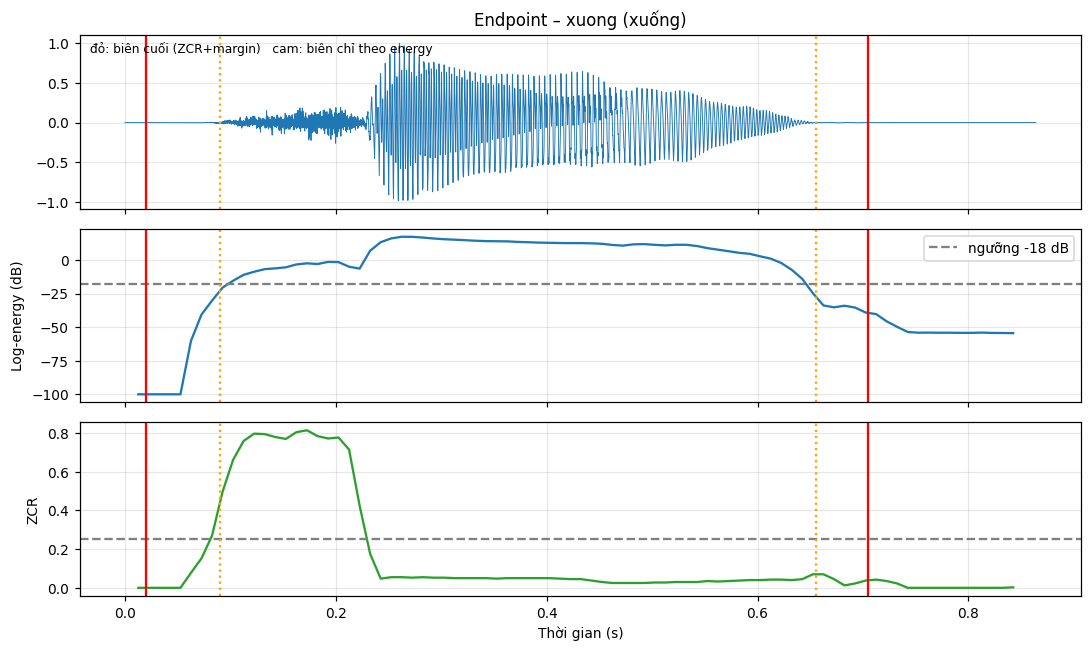

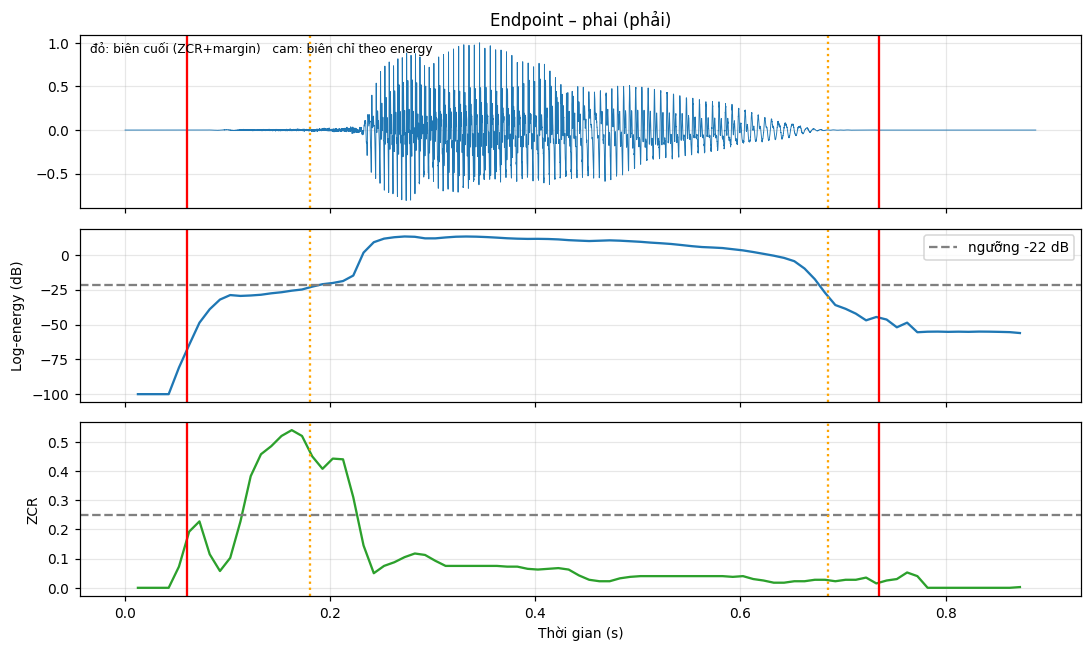

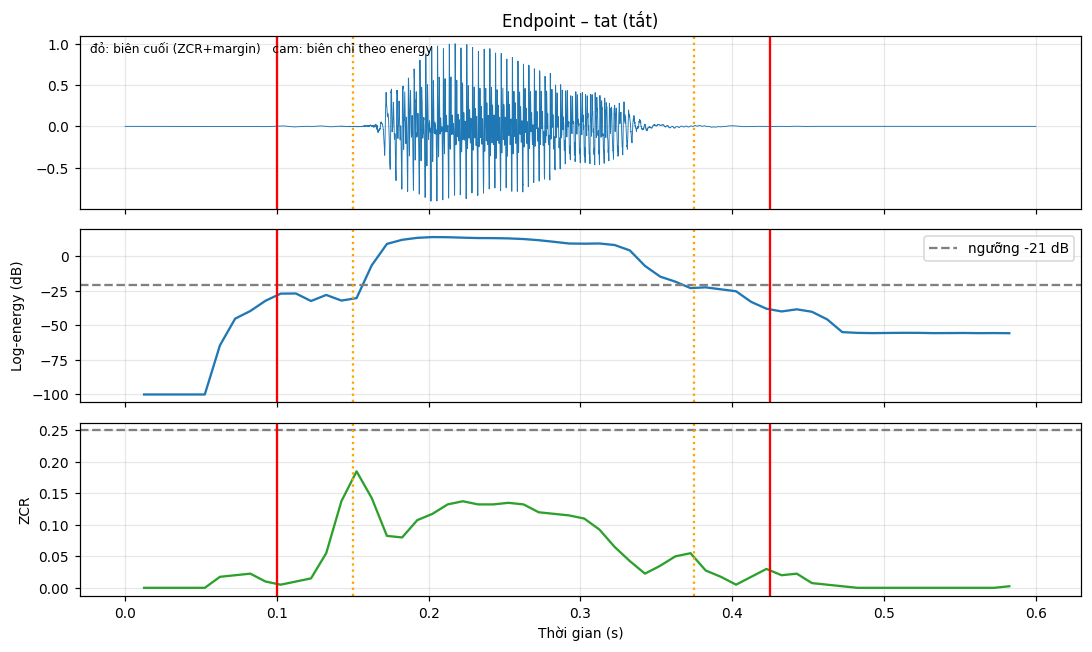

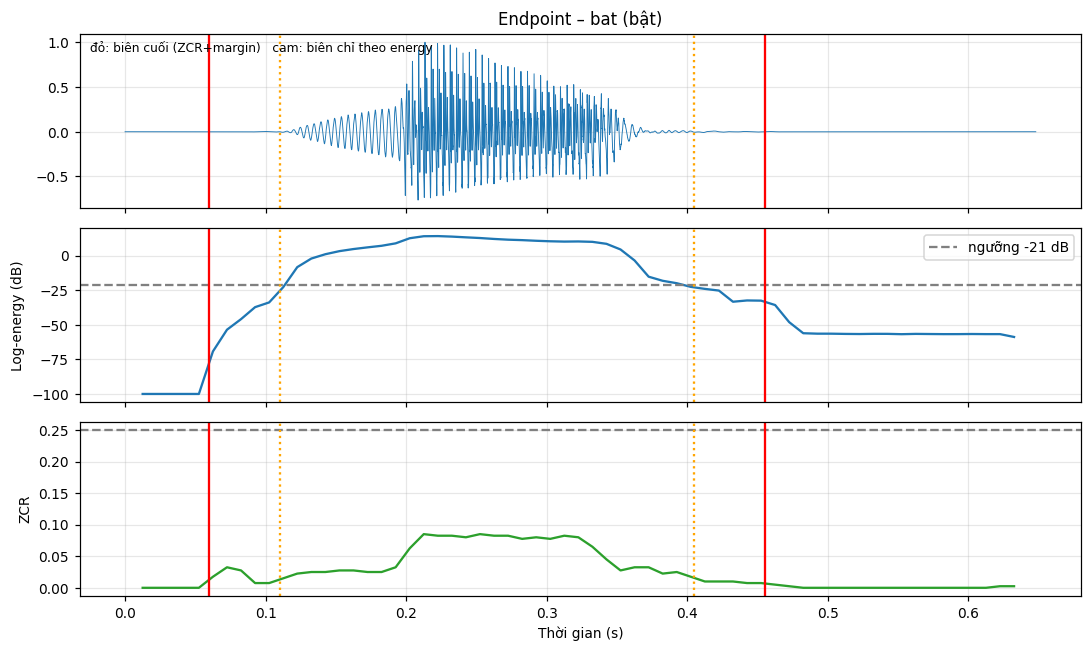

In [ ]:
def endpoint_detect(y, top_db=TOP_DB, margin_frames=MARGIN_FRAMES, zcr_thr=0.25, zcr_ext=10, use_zcr=True):
    f = short_time_features(y); E, Z = f['Edb'], f['ZCR']; n = len(E)
    noise = np.percentile(E, 10)                       # nền nhiễu ước lượng từ các frame yên tĩnh nhất
    thr = max(E.max()-top_db, noise+10)                # ngưỡng energy tương đối
    idx = np.where(E > thr)[0]; s0, e0 = int(idx[0]), int(idx[-1])
    s, e = s0, e0
    if use_zcr:                                        # tinh chỉnh biên: phụ âm vô thanh/xát có ZCR cao, energy thấp
        lo = noise+6
        for _ in range(zcr_ext):
            if s > 0 and Z[s-1] > zcr_thr and E[s-1] > lo: s -= 1
            else: break
        for _ in range(zcr_ext):
            if e < n-1 and Z[e+1] > zcr_thr and E[e+1] > lo: e += 1
            else: break
    s = max(0, s-margin_frames); e = min(n-1, e+margin_frames)
    start, end = s*HOP, min(len(y), e*HOP+WIN)
    return start, end, dict(thr=thr, noise=noise, s0=s0, e0=e0, s=s, e=e, f=f)

def plot_endpoint(y, title, save=None):
    st, en, info = endpoint_detect(y); f = info['f']; t = np.arange(len(y))/FS
    fig, ax = plt.subplots(3, 1, figsize=(10, 6), sharex=True)
    ax[0].plot(t, y, lw=.6); ax[0].set_title(title)
    ax[1].plot(f['t'], f['Edb']); ax[1].axhline(info['thr'], c='gray', ls='--', label=f"ngưỡng {info['thr']:.0f} dB"); ax[1].legend(); ax[1].set_ylabel('Log-energy (dB)')
    ax[2].plot(f['t'], f['ZCR'], c='tab:green'); ax[2].axhline(0.25, c='gray', ls='--'); ax[2].set_ylabel('ZCR'); ax[2].set_xlabel('Thời gian (s)')
    for a in ax:
        a.axvline(info['s0']*HOP/FS, c='orange', ls=':'); a.axvline((info['e0']*HOP+WIN)/FS, c='orange', ls=':')
        a.axvline(st/FS, c='r'); a.axvline(en/FS, c='r')
    ax[0].text(0.01, 0.9, 'đỏ: biên cuối (ZCR+margin)   cam: biên chỉ theo energy', transform=ax[0].transAxes, fontsize=8)
    plt.tight_layout()
    if save: plt.savefig(FIG/save)
    plt.show()

for lab in ['xuong', 'phai', 'tat', 'bat']:
    plot_endpoint(REAL[lab][0], f'Endpoint – {lab} ({VI[lab]})', save=f'C_endpoint_{lab}.png')

In [ ]:
# Xuất file đã trim + so sánh thời lượng trước/sau; đối chiếu để kiểm tra có cắt mất âm không
Path('dataset_trimmed').mkdir(exist_ok=True)
rows = []
for lab in LABELS:
    y = REAL[lab][0]
    st, en, _ = endpoint_detect(y)                                           # cấu hình dùng trong Lab
    st0, en0, _ = endpoint_detect(y, margin_frames=0, use_zcr=False)         # chỉ energy, không margin
    stR, enR, _ = endpoint_detect(y, top_db=55, margin_frames=0, use_zcr=False)  # tham chiếu: ngưỡng rất thấp ≈ toàn bộ vùng có tiếng
    (Path('dataset_trimmed')/lab).mkdir(exist_ok=True)
    sf.write(Path('dataset_trimmed')/lab/f'{lab}_01_trim.wav', y[st:en], FS)
    rows.append(dict(label=lab, truoc_s=len(y)/FS, sau_s=(en-st)/FS,
                     mat_dau_ms_energy_only=max(0, (st0-stR))/FS*1000, mat_cuoi_ms_energy_only=max(0, (enR-en0))/FS*1000,
                     mat_dau_ms_final=max(0, (st-stR))/FS*1000, mat_cuoi_ms_final=max(0, (enR-en))/FS*1000))
tbl = pd.DataFrame(rows).set_index('label'); display(tbl.round(3))
print('Cột "mat_*_ms": số ms âm bị cắt so với biên tham chiếu (ngưỡng 55 dB). 0 nghĩa là không mất âm.')

,truoc_s,sau_s,mat_dau_ms_energy_only,mat_cuoi_ms_energy_only,mat_dau_ms_final,mat_cuoi_ms_final
label,,,,,,
bat,0.648,0.395,30.0,70.0,0.0,20.0
tat,0.600,0.325,80.0,90.0,30.0,40.0
len,0.768,0.585,20.0,20.0,0.0,0.0
xuong,0.864,0.685,20.0,50.0,0.0,0.0
trai,0.864,0.655,40.0,70.0,0.0,20.0
phai,0.888,0.675,110.0,30.0,0.0,0.0
dung,0.744,0.585,20.0,50.0,0.0,0.0


Cột "mat_*_ms": số ms âm bị cắt so với biên tham chiếu (ngưỡng 55 dB). 0 nghĩa là không mất âm.


**Nhận xét C.** Ngưỡng dùng: TOP_DB = 35 dB, sàn = nền nhiễu + 10 dB, tinh chỉnh ZCR > 0.25 (tối đa 10 frame), margin 5 frame = 50 ms. Thời lượng trước → sau trim (từ `_01`): bật 0.648→0.395 s, tắt 0.600→0.325 s, lên 0.768→0.585 s, xuống 0.864→0.685 s, trái 0.864→0.655 s, phải 0.888→0.675 s, dừng 0.744→0.585 s.

**Có cắt mất âm không?** Nếu chỉ dùng ngưỡng energy, không margin, so với biên tham chiếu (ngưỡng 55 dB) bị mất 20–110 ms ở đầu (nặng nhất: `phai` 110 ms, `tat` 80 ms – phụ âm đầu năng lượng thấp) và 20–90 ms ở cuối. Với cấu hình cuối (ZCR + margin) phần mất còn ≤ 40 ms, và bằng 0 ở 4/7 từ (`tat` mất 30 ms đầu/40 ms cuối, `bat` 20 ms cuối, `trai` 20 ms cuối). Phần còn lại phần lớn là đuôi/nền rất yếu gần mức nhiễu, nên chấp nhận được; tuy nhiên mình chưa *nghe lại* file trim (không nghe được trong môi trường này) – bạn nên nghe `dataset_trimmed/` để xác nhận.

## D. MFCC (pre-emphasis α=0.97, Hamming, n_mels=24, n_mfcc=13, CMN)

pre-emphasis: [0.1   0.083 0.025]
bat shape (T, D) = (37, 13)
trai shape (T, D) = (63, 13)
xuong shape (T, D) = (66, 13)


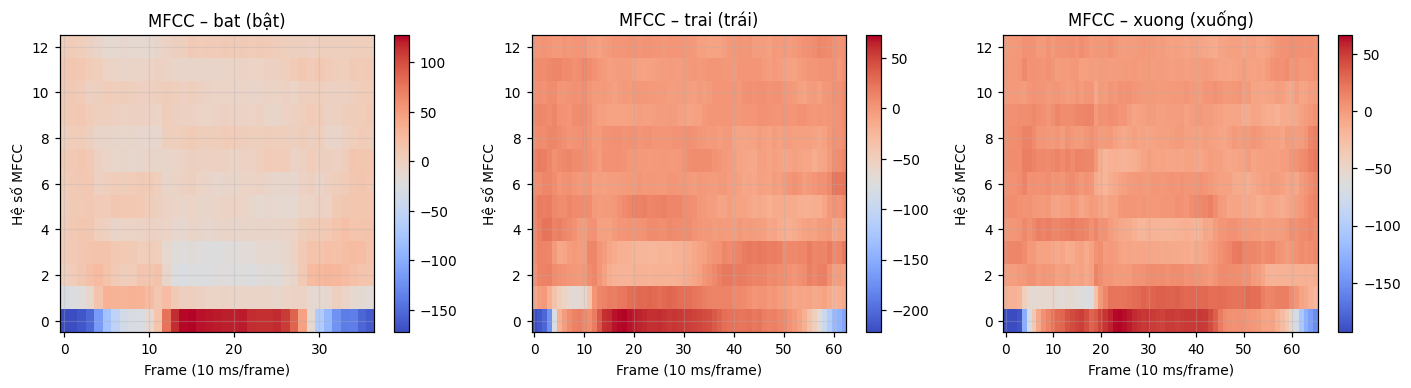

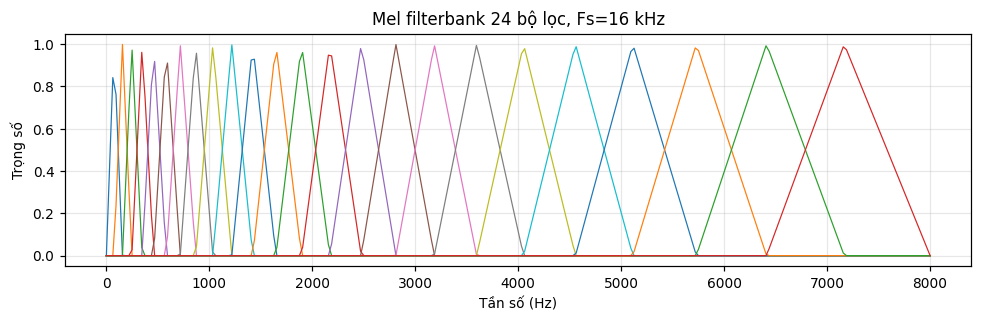

Số frame mỗi từ (sau trim): {'bat': 37, 'trai': 63, 'xuong': 66} | số chiều/frame cố định = 13


In [ ]:
def mfcc_feature(y, delta=False):
    y = lfilter([1.0, -PREEMPH], [1.0], y)                               # pre-emphasis: y[n]=x[n]-0.97x[n-1]
    M = librosa.feature.mfcc(y=y, sr=FS, n_mfcc=N_MFCC, n_mels=N_MELS, n_fft=NFFT,
                             win_length=WIN, hop_length=HOP, window='hamming', center=False, htk=True)
    M = M - np.mean(M, axis=1, keepdims=True)                            # CMN theo từng utterance (giống train/test)
    if delta:
        M = np.vstack([M, librosa.feature.delta(M, width=9, mode='nearest')])   # 13 + 13 Δ
    return M.T                                                           # (T frames, D)

# kiểm tra ví dụ pre-emphasis của đề: x=[0,.1,.18,.2] -> y[1..3]=[.1,.083,.025]
print('pre-emphasis:', np.round(lfilter([1,-0.97],[1],[0,.1,.18,.2])[1:], 3))

feats = {}
for lab in ['bat', 'trai', 'xuong']:
    st, en, _ = endpoint_detect(REAL[lab][0]); feats[lab] = mfcc_feature(REAL[lab][0][st:en])
    print(lab, 'shape (T, D) =', feats[lab].shape)

fig, ax = plt.subplots(1, 3, figsize=(13, 3.6))
for a, lab in zip(ax, feats):
    im = a.imshow(feats[lab].T, origin='lower', aspect='auto', cmap='coolwarm'); a.set_title(f'MFCC – {lab} ({VI[lab]})')
    a.set_xlabel('Frame (10 ms/frame)'); a.set_ylabel('Hệ số MFCC'); plt.colorbar(im, ax=a)
plt.tight_layout(); plt.savefig(FIG/'D_mfcc_heatmaps.png'); plt.show()

# Mel filterbank 24 bộ lọc (thang Mel B(f)=1125 ln(1+f/700) -> htk=True)
mel = librosa.filters.mel(sr=FS, n_fft=NFFT, n_mels=N_MELS, htk=True, norm=None)
plt.figure(figsize=(9, 3)); plt.plot(np.linspace(0, FS/2, mel.shape[1]), mel.T, lw=.8)
plt.xlabel('Tần số (Hz)'); plt.ylabel('Trọng số'); plt.title('Mel filterbank 24 bộ lọc, Fs=16 kHz'); plt.tight_layout(); plt.savefig(FIG/'D_mel_filterbank.png'); plt.show()
print('Số frame mỗi từ (sau trim):', {lab: len(v) for lab, v in feats.items()}, '| số chiều/frame cố định =', N_MFCC)

**Nhận xét D.** Cấu hình: pre-emphasis α = 0.97, Hamming 400 mẫu, hop 160, NFFT 512, 24 bộ lọc Mel (thang HTK 1125·ln(1+f/700)), 13 MFCC, CMN theo từng utterance; train và test dùng chung đúng một hàm `mfcc_feature`. Sau trim, `bat` có 37 frame, `trai` 63 frame, `xuong` 66 frame – mỗi frame luôn là vector 13 chiều.

**Vì sao số frame khác nhau nhưng số chiều cố định?** Số frame T ≈ (độ dài − 400)/160 + 1 phụ thuộc thời lượng từ; còn số chiều là do pipeline quyết định (24 bộ lọc → DCT giữ 13 hệ số), không phụ thuộc độ dài. Do đó mỗi từ là ma trận T×13 với T thay đổi – chính DTW xử lý sự lệch T này.

**Cấu trúc theo thời gian:** `bat` ngắn (37 frame) với một đoạn ổn định ngắn; `trai`/`xuong` dài hơn, có nhiều vùng đổi màu hơn (phụ âm đầu → nguyên âm → đuôi), thấy qua các khối hệ số khác nhau trong heatmap. Hình Mel filterbank cho thấy các bộ lọc dày và hẹp ở < 1 kHz, thưa và rộng dần về 8 kHz.

## E. DTW tự cài đặt (Euclidean local distance, quy hoạch động 3 bước, backtrack, chuẩn hóa theo |P|)

In [ ]:
def local_distance(X, Y):
    """C[i,j] = ||x_i - y_j||_2  (X:(N,D), Y:(M,D))"""
    return np.sqrt(((X[:, None, :]-Y[None, :, :])**2).sum(-1))

def dtw_distance(X, Y):
    """Trả (DTW_norm, path, D (N,M), C (N,M)).  D[i,j]=C[i,j]+min(D[i-1,j], D[i,j-1], D[i-1,j-1])"""
    C = local_distance(X, Y); N, M = C.shape
    Dl = np.full((N+1, M+1), np.inf).tolist(); Dl[0][0] = 0.0
    Bl = np.zeros((N+1, M+1), dtype=int).tolist()           # 0=chéo, 1=dọc (i-1), 2=ngang (j-1)
    Cl = C.tolist()
    for i in range(1, N+1):
        Di, Dp, Ci, Bi = Dl[i], Dl[i-1], Cl[i-1], Bl[i]
        for j in range(1, M+1):
            d, b = Dp[j-1], 0
            if Dp[j] < d: d, b = Dp[j], 1
            if Di[j-1] < d: d, b = Di[j-1], 2
            Di[j] = Ci[j-1] + d; Bi[j] = b
    i, j, path = N, M, []
    while i > 0 or j > 0:                                    # backtracking từ ô cuối
        path.append((i-1, j-1)); b = Bl[i][j]
        if b == 0: i, j = i-1, j-1
        elif b == 1: i -= 1
        else: j -= 1
    path.reverse()
    D = np.array(Dl)[1:, 1:]
    return D[-1, -1]/max(len(path), 1), path, D, C

# ---- Kiểm tra bắt buộc ----
X = feats['bat']; Y = feats['trai']
print('1) DTW(X,X) =', dtw_distance(X, X)[0], '(phải ≈ 0)')
print('2) local_distance khớp scipy.cdist:', np.allclose(local_distance(X, Y), cdist(X, Y)))
tot = dtw_distance(X, Y)[2][-1, -1]
ref = librosa.sequence.dtw(X=X.T, Y=Y.T, metric='euclidean')[0][-1, -1]     # chỉ để đối chiếu, không dùng trong pipeline
print(f'3) Tổng chi phí DTW tự cài = {tot:.4f} | librosa.sequence.dtw = {ref:.4f} | khớp: {np.isclose(tot, ref)}')
print('4) Ví dụ của đề: d([1,2],[4,6]) =', local_distance(np.array([[1., 2.]]), np.array([[4., 6.]]))[0, 0])

1) DTW(X,X) = 0.0 (phải ≈ 0)
2) local_distance khớp scipy.cdist: True
3) Tổng chi phí DTW tự cài = 3299.8539 | librosa.sequence.dtw = 3299.8539 | khớp: True
4) Ví dụ của đề: d([1,2],[4,6]) = 5.0


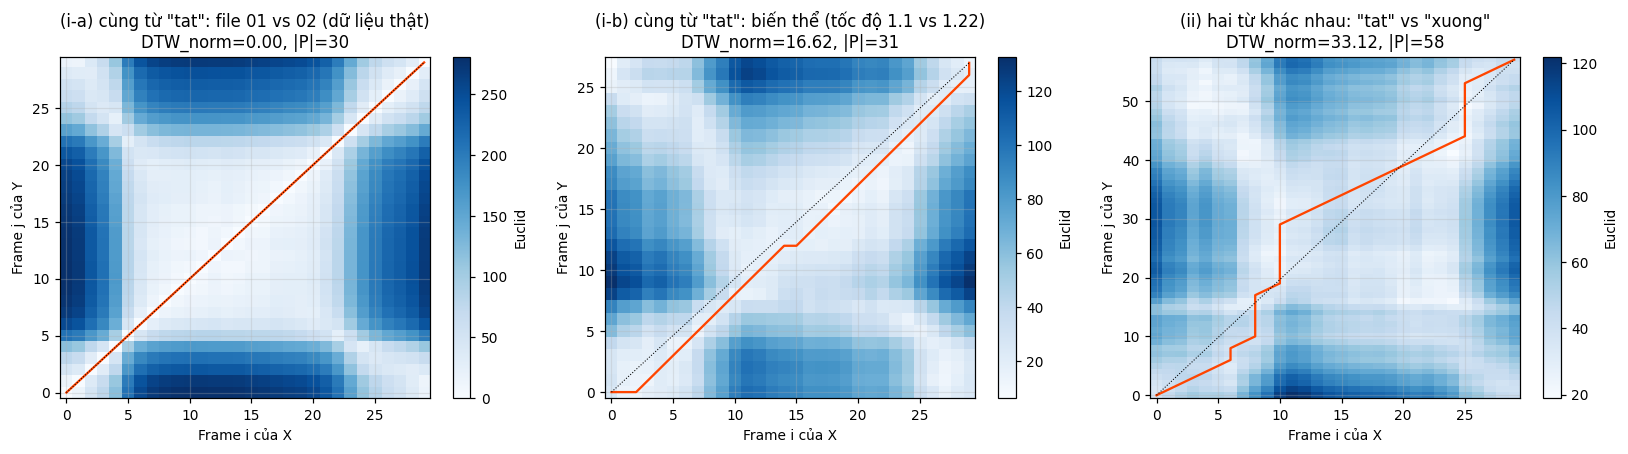

                        DTW_norm  |P|
cùng từ – dữ liệu thật     0.000   30
cùng từ – tăng cường      16.617   31
khác từ                   33.121   58


In [ ]:
def prepare(y, trim=True, delta=False):
    if trim:
        s, e, _ = endpoint_detect(y); y = y[s:e]
    return mfcc_feature(y, delta=delta)

def plot_dtw(X, Y, title, ax):
    nrm, path, D, C = dtw_distance(X, Y); p = np.array(path)
    im = ax.imshow(C.T, origin='lower', aspect='auto', cmap='Blues'); ax.plot(p[:, 0], p[:, 1], c='orangered', lw=1.5)
    ax.plot([0, C.shape[0]-1], [0, C.shape[1]-1], c='k', ls=':', lw=.7)
    ax.set_xlabel('Frame i của X'); ax.set_ylabel('Frame j của Y'); ax.set_title(f'{title}\nDTW_norm={nrm:.2f}, |P|={len(path)}')
    plt.colorbar(im, ax=ax, label='Euclid'); return nrm, len(path)

lab = 'tat'; other = 'xuong'
X_real = prepare(REAL[lab][0]);  Y_real = prepare(REAL[lab][1])               # cùng từ, 2 file "thật" (thực ra trùng bản ghi)
X_aug  = prepare(AUG[lab][0]);   Y_aug  = prepare(AUG[lab][3])                # cùng từ, tăng cường (tốc độ khác nhau)
Z_oth  = prepare(AUG[other][0])                                               # từ khác
fig, ax = plt.subplots(1, 3, figsize=(15, 4.2))
r1 = plot_dtw(X_real, Y_real, f'(i-a) cùng từ "{lab}": file 01 vs 02 (dữ liệu thật)', ax[0])
r2 = plot_dtw(X_aug,  Y_aug,  f'(i-b) cùng từ "{lab}": biến thể (tốc độ {AUG_RATE[lab][0]} vs {AUG_RATE[lab][3]})', ax[1])
r3 = plot_dtw(X_aug,  Z_oth,  f'(ii) hai từ khác nhau: "{lab}" vs "{other}"', ax[2])
plt.tight_layout(); plt.savefig(FIG/'E_dtw_paths.png'); plt.show()
print(pd.DataFrame({'DTW_norm': [r1[0], r2[0], r3[0]], '|P|': [r1[1], r2[1], r3[1]]},
                   index=['cùng từ – dữ liệu thật', 'cùng từ – tăng cường', 'khác từ']).round(3))

**Nhận xét E.** DTW tự cài (Euclid local distance, quy hoạch động 3 bước, backtrack, chia cho |P|) đã được kiểm chứng: DTW(X,X)=0; local distance khớp `scipy.cdist`; tổng chi phí khớp `librosa.sequence.dtw` đến 4 chữ số (3299.8539) – thư viện chỉ dùng để đối chiếu.

| Trường hợp | DTW_norm | \|P\| | Path |
|---|---|---|---|
| (i-a) cùng từ `tat`, file 01 vs 02 (thật) | 0.00 | 30 | trùng hoàn toàn đường chéo (vì 2 file là cùng 1 bản ghi) |
| (i-b) cùng từ `tat`, 2 biến thể tăng cường | 16.62 | 31 | lệch khỏi đường chéo, có đoạn ngang/dọc do khác tốc độ |
| (ii) khác từ `tat` vs `xuong` | 33.12 | 58 | gấp khúc, nhiều bước dọc dài (bị ép khớp) |

Chi phí tăng gần **2×** khi khác từ (16.6 → 33.1) và path dài gần gấp đôi (|P| 58) vì hai chuỗi có cấu trúc âm học khác nhau, DTW phải kéo giãn mạnh mà vẫn không tìm được các frame giống nhau.

## F. Bộ nhận dạng nearest-template (3 template/từ, luật `D_w(X)=min_r DTW_norm`)

In [ ]:
def evaluate(data, trim=True, delta=False, n_templates=3):
    """data: {lab: [5 mảng âm thanh]}. Template = file 01..n_templates; test = file 04, 05."""
    fe = {lab: [prepare(y, trim, delta) for y in data[lab]] for lab in LABELS}
    templates = {lab: fe[lab][:n_templates] for lab in LABELS}
    rows = []
    for lab in LABELS:
        for k in (3, 4):
            X = fe[lab][k]
            scores = {w: min(dtw_distance(X, R)[0] for R in refs) for w, refs in templates.items()}
            rk = sorted(scores.items(), key=lambda kv: kv[1])
            rows.append(dict(test_file=f'{lab}_{k+1:02d}.wav', true_label=lab, pred_label=rk[0][0],
                             top1_label=rk[0][0], top1_dtw=rk[0][1], top2_label=rk[1][0], top2_dtw=rk[1][1],
                             top3_label=rk[2][0], top3_dtw=rk[2][1], scores=scores))
    df = pd.DataFrame(rows)
    return df, accuracy_score(df.true_label, df.pred_label), confusion_matrix(df.true_label, df.pred_label, labels=LABELS)

def recognize(path, templates, trim=True, delta=False):
    """Nhận file WAV chưa biết -> (nhãn, khoảng cách DTW, bảng điểm đã sắp xếp)"""
    X = prepare(load_audio(path), trim, delta)
    sc = {w: min(dtw_distance(X, R)[0] for R in refs) for w, refs in templates.items()}
    sc = dict(sorted(sc.items(), key=lambda kv: kv[1])); w = next(iter(sc)); return w, sc[w], sc

def build_templates(root, n=3, trim=True, delta=False):
    return {lab: [prepare(load_audio(f), trim, delta) for f in sorted((Path(root)/lab).glob('*.wav'))[:n]] for lab in LABELS}

df_real, acc_real, cm_real = evaluate(REAL)
df_aug,  acc_aug,  cm_aug  = evaluate(AUG)
print(f'Accuracy – dữ liệu THẬT (có leakage): {acc_real*100:.1f}%   |   dữ liệu TĂNG CƯỜNG: {acc_aug*100:.1f}%')
cols = ['test_file','true_label','pred_label','top1_label','top1_dtw','top2_label','top2_dtw','top3_label','top3_dtw']
print('\nTop-3 nhãn gần nhất – dữ liệu tăng cường (7 test file đầu):'); display(df_aug[cols].head(7).round(3))
print('Top-3 nhãn gần nhất – dữ liệu thật (5 test file đầu):'); display(df_real[cols].head(5).round(3))

Accuracy – dữ liệu THẬT (có leakage): 100.0%   |   dữ liệu TĂNG CƯỜNG: 100.0%

Top-3 nhãn gần nhất – dữ liệu tăng cường (7 test file đầu):


,test_file,true_label,pred_label,top1_label,top1_dtw,top2_label,top2_dtw,top3_label,top3_dtw
0,bat_04.wav,bat,bat,bat,14.952,tat,21.301,len,25.333
1,bat_05.wav,bat,bat,bat,16.682,phai,20.013,trai,22.079
2,tat_04.wav,tat,tat,tat,14.169,bat,17.954,phai,22.821
3,tat_05.wav,tat,tat,tat,16.208,bat,19.569,phai,24.468
4,len_04.wav,len,len,len,13.774,bat,22.575,dung,23.508
5,len_05.wav,len,len,len,16.146,dung,21.534,tat,24.790
6,xuong_04.wav,xuong,xuong,xuong,13.803,dung,20.655,trai,23.842


Top-3 nhãn gần nhất – dữ liệu thật (5 test file đầu):


,test_file,true_label,pred_label,top1_label,top1_dtw,top2_label,top2_dtw,top3_label,top3_dtw
0,bat_04.wav,bat,bat,bat,0.0,tat,35.904,len,39.389
1,bat_05.wav,bat,bat,bat,0.0,tat,35.904,len,39.389
2,tat_04.wav,tat,tat,tat,0.0,phai,34.004,len,34.875
3,tat_05.wav,tat,tat,tat,0.0,phai,34.004,len,34.875
4,len_04.wav,len,len,len,0.0,dung,31.534,tat,34.875


In [ ]:
# Demo bắt buộc: nhận dạng một file WAV chưa biết bằng templates lưu từ dataset_aug (test = biến thể 04)
tpl_demo = build_templates('dataset_aug')
w, d, sc = recognize('dataset_aug/xuong/xuong_04.wav', tpl_demo)
print(f'File: xuong_04.wav -> dự đoán "{w}" ({VI[w]}), khoảng cách DTW_norm = {d:.3f}')
print({k: round(v, 3) for k, v in list(sc.items())[:3]})

File: xuong_04.wav -> dự đoán "xuong" (xuống), khoảng cách DTW_norm = 13.803
{'xuong': np.float64(13.803), 'dung': np.float64(20.656), 'trai': np.float64(23.842)}


**Nhận xét F.** Mỗi test file được: trim → MFCC → DTW tới toàn bộ 21 template (7 từ × 3) → chọn nhãn có `min DTW_norm`. Trên dữ liệu tăng cường, top-1 luôn cách top-2 rõ rệt (ví dụ `bat_04`: 14.95 so với 21.30 của `tat`; `xuong_04`: 13.80 so với 20.66 của `dung`). Trên dữ liệu thật, top-1 = 0.000 cho mọi file: dấu hiệu rõ của leakage chứ không phải hệ thống 'hoàn hảo'. Hàm `recognize(path, templates)` nhận một file WAV chưa biết và trả nhãn + khoảng cách DTW (demo bên trên: `xuong_04.wav → xuong`, 13.803).

## G. Đánh giá, confusion matrix và thí nghiệm E1–E4

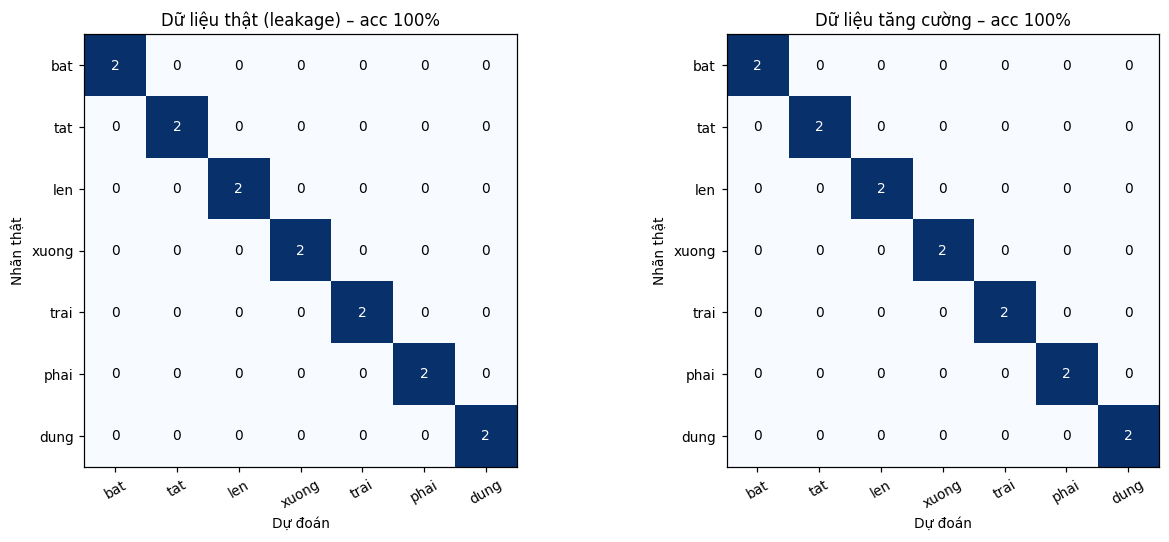

[[2 0 0 0 0 0 0]
 [0 2 0 0 0 0 0]
 [0 0 2 0 0 0 0]
 [0 0 0 2 0 0 0]
 [0 0 0 0 2 0 0]
 [0 0 0 0 0 2 0]
 [0 0 0 0 0 0 2]]


In [ ]:
def plot_cm(cm, title, ax):
    im = ax.imshow(cm, cmap='Blues'); ax.set_xticks(range(len(LABELS))); ax.set_yticks(range(len(LABELS)))
    ax.set_xticklabels(LABELS, rotation=30); ax.set_yticklabels(LABELS); ax.set_xlabel('Dự đoán'); ax.set_ylabel('Nhãn thật'); ax.set_title(title)
    for i in range(len(LABELS)):
        for j in range(len(LABELS)): ax.text(j, i, cm[i, j], ha='center', va='center', color='w' if cm[i, j] > cm.max()/2 else 'k')
    ax.grid(False)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
plot_cm(cm_real, f'Dữ liệu thật (leakage) – acc {acc_real*100:.0f}%', ax[0])
plot_cm(cm_aug,  f'Dữ liệu tăng cường – acc {acc_aug*100:.0f}%', ax[1])
plt.tight_layout(); plt.savefig(FIG/'G_confusion_matrix.png'); plt.show()
print(confusion_matrix(df_aug.true_label, df_aug.pred_label, labels=LABELS))

In [ ]:
# ---- E1: có/không endpoint | E2: 13 MFCC vs 13+Δ | E3: 1 vs 3 template ----
exp = []
for name, kw in [('Baseline (trim, 13 MFCC, 3 tpl)', {}), ('E1: KHÔNG trim', dict(trim=False)),
                 ('E2: 13 MFCC + Δ', dict(delta=True)), ('E3: 1 template/từ', dict(n_templates=1))]:
    dr, ar, _ = evaluate(REAL, **kw); da, aa, _ = evaluate(AUG, **kw)
    exp.append({'Thí nghiệm': name, 'Acc dữ liệu thật (leakage) %': ar*100, 'Acc tăng cường %': aa*100,
                'DTW_norm TB đúng nhãn (tăng cường)': da.top1_dtw[da.true_label == da.pred_label].mean(),
                'Margin top2−top1 TB (tăng cường)': (da.top2_dtw-da.top1_dtw).mean()})
    err = da[da.true_label != da.pred_label]
    for _, r in err.iterrows(): print(f'  [{name}] nhầm: {r.test_file} (thật={r.true_label}) -> {r.pred_label}; top1={r.top1_dtw:.2f}, top2={r.top2_label} {r.top2_dtw:.2f}; điểm đúng nhãn={r.scores[r.true_label]:.2f}')
exp = pd.DataFrame(exp).set_index('Thí nghiệm'); display(exp.round(3))
print('E4 (same vs cross-speaker): KHÔNG thực hiện – chỉ có dữ liệu của một người nói (đề: "nếu có dữ liệu hai người").')

  [E3: 1 template/từ] nhầm: trai_04.wav (thật=trai) -> phai; top1=22.51, top2=xuong 25.12; điểm đúng nhãn=25.49


,Acc dữ liệu thật (leakage) %,Acc tăng cường %,DTW_norm TB đúng nhãn (tăng cường),Margin top2−top1 TB (tăng cường)
Thí nghiệm,,,,
"Baseline (trim, 13 MFCC, 3 tpl)",100.0,100.000,15.344,6.251
E1: KHÔNG trim,100.0,100.000,14.413,5.468
E2: 13 MFCC + Δ,100.0,100.000,15.765,6.517
E3: 1 template/từ,100.0,92.857,16.851,6.154


E4 (same vs cross-speaker): KHÔNG thực hiện – chỉ có dữ liệu của một người nói (đề: "nếu có dữ liệu hai người").


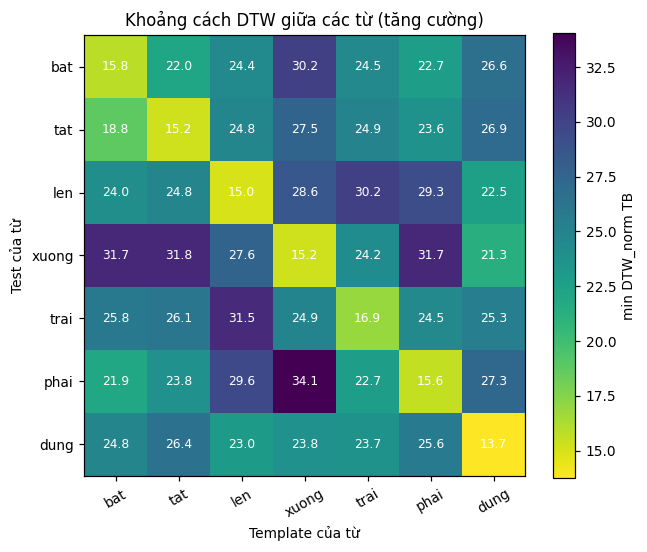

Cặp từ gần nhau nhất (dễ nhầm nhất): bat – tat  (khoảng cách ≈ 20.40); khoảng cách cùng từ TB = 15.34
Đã lưu results.csv và results_augmented.csv


In [ ]:
# Ma trận khoảng cách trung bình giữa các từ (test vs template) -> tìm cặp từ dễ nhầm nhất
fe = {lab: [prepare(y) for y in AUG[lab]] for lab in LABELS}
Dm = np.zeros((len(LABELS), len(LABELS)))
for i, a in enumerate(LABELS):
    for j, b in enumerate(LABELS):
        Dm[i, j] = np.mean([min(dtw_distance(X, R)[0] for R in fe[b][:3]) for X in fe[a][3:]])
plt.figure(figsize=(6, 5)); plt.imshow(Dm, cmap='viridis_r'); plt.colorbar(label='min DTW_norm TB')
plt.xticks(range(7), LABELS, rotation=30); plt.yticks(range(7), LABELS); plt.xlabel('Template của từ'); plt.ylabel('Test của từ')
for i in range(7):
    for j in range(7): plt.text(j, i, f'{Dm[i, j]:.1f}', ha='center', va='center', color='w', fontsize=8)
plt.grid(False); plt.title('Khoảng cách DTW giữa các từ (tăng cường)'); plt.tight_layout(); plt.savefig(FIG/'G_word_distance.png'); plt.show()
off = Dm + np.diag([np.inf]*7); 
sym = (off + off.T)/2; i, j = np.unravel_index(np.argmin(sym), sym.shape)
print(f'Cặp từ gần nhau nhất (dễ nhầm nhất): {LABELS[i]} – {LABELS[j]}  (khoảng cách ≈ {sym[i, j]:.2f}); khoảng cách cùng từ TB = {np.mean(np.diag(Dm)):.2f}')

# ---- results.csv (theo mục 7 của đề) ----
res = df_real[['test_file','true_label','pred_label','top1_label','top1_dtw','top2_label','top2_dtw']].copy()
res['note'] = 'dữ liệu thật: test trùng byte với template (leakage)'
res.round(4).to_csv('results.csv', index=False, encoding='utf-8-sig')
df_aug[['test_file','true_label','pred_label','top1_label','top1_dtw','top2_label','top2_dtw']].round(4).to_csv('results_augmented.csv', index=False, encoding='utf-8-sig')
print('Đã lưu results.csv và results_augmented.csv')

**Nhận xét G.** Accuracy: 100% (14/14) trên cả hai bộ ở cấu hình baseline; confusion matrix là ma trận đường chéo. Vì chỉ có 14 mẫu test và đều sinh từ một bản ghi, một lỗi đã làm accuracy tụt 7.1 điểm – kết quả dưới đây là *định tính*, chưa có ý nghĩa thống kê.

- **E1 (trim vs không trim):** accuracy không đổi (100%), nhưng margin top2−top1 giảm từ 6.25 (có trim) xuống 5.47 (không trim): silence khớp nhau 'rẻ' làm khoảng cách giữa từ đúng và từ sai bị nén lại; trim làm hệ thống phân biệt tốt hơn dù chưa đủ để đổi nhãn trên bộ nhỏ này.
- **E2 (13 MFCC vs 13 MFCC + Δ):** accuracy giữ 100%; margin tăng nhẹ 6.25 → 6.52 nên Δ có ích rất ít ở đây (không có lỗi nào để giảm).
- **E3 (1 vs 3 template):** accuracy 100% → 92.9%: `trai_04` bị nhầm thành `phai` (22.51 so với 25.49 của nhãn đúng) khi chỉ có 1 template; 3 template sửa được lỗi này vì lấy min trên nhiều cách phát âm/tốc độ.
- **E4 (same vs cross-speaker):** *không thực hiện* – chỉ có dữ liệu một người nói.

**Cặp từ dễ nhầm nhất** (theo ma trận khoảng cách DTW trung bình giữa các từ): `bat`–`tat` (≈ 20.4, so với 15.3 của cùng từ). Giả thuyết: cả hai là đơn âm tiết ngắn (0.395 s và 0.325 s sau trim), cùng kết thúc bằng phụ âm tắc /t/ và nguyên âm ngắn nên quỹ đạo MFCC gần nhau; khác biệt chính chỉ ở phụ âm đầu rất ngắn /b/ vs /t/. Cặp thứ hai đáng chú ý là `trai`→`phai` (lỗi thực tế ở E3), cùng vần /ai/. Đây là suy luận từ khoảng cách DTW, cần kiểm chứng lại bằng dữ liệu thật.

## Trả lời câu hỏi báo cáo

**1. Vì sao không dùng toàn bộ waveform làm template?** Waveform dài khác nhau, không thẳng hàng theo thời gian, và mẫu-theo-mẫu rất nhạy với pha/biên độ/pitch nên hai lần nói cùng một từ gần như không giống nhau ở mức mẫu; đồng thời silence đầu/cuối bị tính vào khoảng cách. Dùng đặc trưng phổ theo frame (MFCC) sau endpoint detection rồi căn chỉnh bằng DTW mới so sánh được.

**2. Vai trò của energy và ZCR trong endpoint detection.** Log-energy tách vùng có tiếng khỏi nền (chênh ~70 dB trong dữ liệu này) nhưng bỏ sót phụ âm vô thanh/xát năng lượng thấp. ZCR cao (0.45–0.70 ở `xuong`, `trai`, `phai`, `dung`) giúp phát hiện các đoạn đó để mở rộng biên; kết quả: phần bị cắt giảm từ tối đa 110 ms xuống ≤ 40 ms.

**3. Vì sao filterbank Mel rộng dần theo Hz?** Tai người phân giải tần số mịn ở thấp tần và thô ở cao tần; thang Mel gần tuyến tính dưới ~1 kHz và logarit phía trên. Bộ lọc cách đều trên thang Mel nên khi đổi về Hz thì dày và hẹp ở thấp tần, thưa và rộng ở cao tần (Hình Mel filterbank).

**4. Vai trò của log và DCT.** Log nén dynamic range (energy có thể chênh hàng chục dB), gần với cảm nhận độ lớn, và biến quan hệ nhân (nguồn × bộ lọc/kênh) thành cộng nên CMN trừ được thành phần kênh ổn định. DCT biến 24 log-energy filterbank thành các hệ số cepstral ít tương quan; hệ số thấp (13 đầu) mô tả đường bao phổ, bỏ chi tiết mịn như pitch.

**5. Ý nghĩa bước chéo/ngang/dọc.** Bước chéo (i−1,j−1): hai chuỗi cùng tiến một frame (tốc độ tương đương). Bước dọc (i−1,j) và ngang (i,j−1): một frame của chuỗi này khớp với nhiều frame liên tiếp của chuỗi kia, tức một chuỗi bị kéo giãn/nén theo thời gian.

**6. Vì sao chuẩn hóa theo path length?** Tổng chi phí là tổng các local distance trên path nên tỉ lệ với độ dài path; không chia thì từ dài (hoặc so với template dài) luôn bị thiệt. Chia cho |P| cho chi phí trung bình mỗi cặp frame, so sánh công bằng giữa các utterance có độ dài khác nhau.

**7. Nguyên nhân cùng một từ có MFCC khác nhau:** (a) tốc độ nói và nhịp từng âm tiết khác nhau; (b) pitch/cường độ/ngữ điệu và cách phát âm (đồng phát âm) thay đổi; (c) khoảng cách micro, mức âm lượng, kênh thu và nhiễu nền; (d) endpoint cắt khác nhau.

**8. Cặp từ dễ nhầm nhất.** Theo ma trận khoảng cách: `bat`–`tat` (≈ 20.4 so với 15.3 cùng từ); lỗi nhận dạng duy nhất (E3) là `trai_04 → phai`. Nguyên nhân giả thuyết đã nêu ở phần G (đơn âm tiết ngắn, cùng đuôi /t/, hoặc cùng vần /ai/). Do confusion matrix của baseline không có ô ngoài đường chéo, việc phân tích sâu hơn bằng MFCC/path cần dữ liệu thật nhiều lần ghi.

**9. Hạn chế với người nói mới.** Template DTW là mẫu của đúng người/kênh đã ghi; người mới có đường bao phổ, pitch, tốc độ khác nên khoảng cách tăng và không có mô hình thống kê của sự biến thiên; thêm người nói/từ mới thì phải lưu thêm template và chi phí DTW tăng theo số template. Chương 3 giải quyết bằng mô hình thống kê (HMM/GMM) huấn luyện trên nhiều người nói, kết hợp mô hình ngôn ngữ và từ điển phát âm, cùng các kỹ thuật thích nghi người nói.

## Bảng tham số và kết luận

| Tham số | Giá trị |
|---|---|
| Fs, frame, hop | 16 kHz, 25 ms (400), 10 ms (160) |
| Window, pre-emphasis, NFFT | Hamming, α=0.97, 512 |
| Mel filters, MFCC, CMN | 24, 13, có |
| Endpoint | TOP_DB 35, sàn nhiễu+10 dB, ZCR>0.25 (≤10 frame), margin 5 frame |
| DTW | Euclid, 3 bước (chéo/dọc/ngang), chuẩn hóa /\|P\|; luật min trên template |
| Split | 01–03 template, 04–05 test |

**Kết luận.** Pipeline đầy đủ (endpoint → MFCC → DTW tự cài → nearest-template → confusion matrix) chạy đúng và được kiểm chứng với `librosa.sequence.dtw`. Tuy nhiên, dữ liệu thật hiện chỉ có **một bản ghi/từ** nên mọi con số accuracy ở đây chưa phản ánh năng lực nhận dạng. Việc cần làm trước khi nộp: ghi âm 5 lần nói thật cho mỗi từ (nên thêm người thứ hai để làm E4), đặt vào `dataset/<nhãn>/`, rồi chạy lại notebook từ đầu và cập nhật các nhận xét theo số liệu mới.